# NLP Lab : Week 4 (Exercises)
## Module 9: Comparing BERT, GPT-2, RoBERTa, and DistilBERT for Body Performance Classification

## Important Note

This notebook follows the same structure as the starter but uses the **Body Performance** dataset :
a four-class problem. Fill in every `??` placeholder to complete the notebook.

### Key Changes from Starter Notebook

| Setting | Starter (Diabetes) | Exercises (Body Performance) |
|---------|-------------------|------------------------------|
| Dataset | diabetes.csv : binary (0 / 1) | bodyPerformance.csv : 4 classes (A / B / C / D) |
| `NUM_CLASSES` | 2 (hard-coded) | `len(set(y_train))` |
| `num_labels` | 2 | `NUM_CLASSES` |
| Loss | `CrossEntropyLoss` (weighted) | `CrossEntropyLoss` |
| Precision / Recall / F1 | `average='binary'` (default) | `average='weighted'` |
| ROC-AUC | `roc_auc_score(y, proba[:, 1])` : binary | `roc_auc_score(y, proba, multi_class='ovr', average='weighted')` |
| Confusion matrix labels | `['No Diabetes', 'Diabetes']` | `['A', 'B', 'C', 'D']` |
| Sort results by | Accuracy | F1 |


### Section 0: Set-up and Libraries
> Have a look at the new libraries compared with Week 3.

In [8]:
# Standard libraries
import time
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
)

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# HuggingFace Transformers
from transformers import AutoTokenizer, AutoModelForSequenceClassification, logging
from torch.optim import AdamW

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# Hyperparameters
MAX_LENGTH = 128   # body performance text strings are longer (11 features)
BATCH_SIZE = 16
NUM_EPOCHS = 3
LR         = 2e-5


Device: cpu


### Section 1: Load and Inspect the Dataset
> Download the body performance CSV from this [Kaggle Dataset](https://www.kaggle.com/datasets/kukuroo3/body-performance-data) and place it in the same directory as this notebook.

Expected file: `bodyPerformance.csv`

The dataset contains 11 features:
age, gender, height\_cm, weight\_kg, body fat %, diastolic, systolic,
gripForce, sit and bend forward\_cm, sit-ups counts, broad jump\_cm

**Target Variable:** `class` : A (best), B, C, D (weakest)


In [9]:
# Load the dataset
df = pd.read_csv('bodyPerformance.csv')

print('Shape:', df.shape)
display(df.head())
df.info()

# Separate features and target
feature_cols = [c for c in df.columns if c != 'class']
X_df = df[feature_cols]

# Encode class labels: A→0, B→1, C→2, D→3
le = LabelEncoder()
y  = le.fit_transform(df['class'])   # integer array
CLASS_NAMES = le.classes_.tolist()   # ['A', 'B', 'C', 'D']

print('\nClass mapping:', dict(zip(CLASS_NAMES, le.transform(CLASS_NAMES))))
print('Class distribution:')
print(pd.Series(df['class']).value_counts().sort_index())

# Train / test split (use a 2000 / 500 subset for practical runtimes;
# remove .iloc[:2500] to train on the full dataset)
df_sub = df.sample(n=2500, random_state=42)
X_sub  = df_sub[feature_cols]
y_sub  = le.transform(df_sub['class'])

X_train_df, X_test_df, y_train, y_test = train_test_split(
    X_sub, y_sub,
    test_size=0.2, random_state=42, stratify=y_sub
)

# Derive number of classes from training labels
NUM_CLASSES = len(set(y_train))

print(f'\nTraining samples : {len(y_train)}')
print(f'Test samples     : {len(y_test)}')
print(f'Number of classes: {NUM_CLASSES}')
print(f'Class names      : {CLASS_NAMES}')


Shape: (13393, 12)


,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,M,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,M,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


<class 'pandas.DataFrame'>
RangeIndex: 13393 entries, 0 to 13392
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      13393 non-null  float64
 1   gender                   13393 non-null  str    
 2   height_cm                13393 non-null  float64
 3   weight_kg                13393 non-null  float64
 4   body fat_%               13393 non-null  float64
 5   diastolic                13393 non-null  float64
 6   systolic                 13393 non-null  float64
 7   gripForce                13393 non-null  float64
 8   sit and bend forward_cm  13393 non-null  float64
 9   sit-ups counts           13393 non-null  float64
 10  broad jump_cm            13393 non-null  float64
 11  class                    13393 non-null  str    
dtypes: float64(10), str(2)
memory usage: 1.2 MB

Class mapping: {'A': np.int64(0), 'B': np.int64(1), 'C': np.int64(2), 'D': np.int64(3)}
Class di

### Section 2: Text Serialisation, Dataset Class, and DataLoader Helper

Each row is converted into a descriptive text string before tokenisation.
Complete the `serialise_row` function below.


In [10]:
def serialise_row(row: pd.Series) -> str:
    """
    Convert a single tabular row into a descriptive text string.
    Integer-valued features are printed without a decimal point;
    float-valued features are rounded to two decimal places.
    """
    parts = []
    for col, val in row.items():
        if isinstance(val, float) and val != int(val):
            parts.append(f'{col}: {val:.2f}')
        else:
            parts.append(f'{col}: {val}')  # gender 'M'/'F' is a string
    return ', '.join(parts)


train_texts = [serialise_row(row) for _, row in X_train_df.iterrows()]
test_texts  = [serialise_row(row) for _, row in X_test_df.iterrows()]

print('Example serialised row:')
print(train_texts[0])
print('\nLabel:', y_train[0], '→', CLASS_NAMES[y_train[0]])


Example serialised row:
age: 61.0, gender: M, height_cm: 178.0, weight_kg: 64.90, body fat_%: 21.20, diastolic: 78.0, systolic: 151.0, gripForce: 40.30, sit and bend forward_cm: 11.50, sit-ups counts: 30.0, broad jump_cm: 168.0

Label: 1 → B


In [11]:
class TextDataset(Dataset):
    """Wraps tokenised text encodings and integer labels for PyTorch."""
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


def create_dataloaders(tokenizer, train_texts, y_train,
                       test_texts, y_test,
                       max_length=MAX_LENGTH, batch_size=BATCH_SIZE):
    """Tokenise the train and test text lists and return (train_loader, test_loader)."""
    train_enc = tokenizer(
        train_texts, truncation=True, padding=True, max_length=max_length
    )
    test_enc  = tokenizer(
        test_texts,  truncation=True, padding=True, max_length=max_length
    )
    train_loader = DataLoader(
        TextDataset(train_enc, list(y_train)),
        batch_size=batch_size, shuffle=True
    )
    test_loader  = DataLoader(
        TextDataset(test_enc,  list(y_test)),
        batch_size=batch_size, shuffle=False
    )
    return train_loader, test_loader


### Section 3: Tokenisers and DataLoaders

GPT-2 has no dedicated padding token : complete the fix below.


In [12]:
# ── BERT ──────────────────────────────────────────────────────────────────
bert_tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
bert_train_loader, bert_test_loader = create_dataloaders(
    bert_tokenizer, train_texts, y_train, test_texts, y_test
)

# ── GPT-2 ─────────────────────────────────────────────────────────────────
gpt2_tokenizer = AutoTokenizer.from_pretrained('gpt2')
# GPT-2 has no pad token : assign the EOS token as the pad token
gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token
gpt2_train_loader, gpt2_test_loader = create_dataloaders(
    gpt2_tokenizer, train_texts, y_train, test_texts, y_test
)

# ── RoBERTa ───────────────────────────────────────────────────────────────
roberta_tokenizer = AutoTokenizer.from_pretrained('roberta-base')
roberta_train_loader, roberta_test_loader = create_dataloaders(
    roberta_tokenizer, train_texts, y_train, test_texts, y_test
)

# ── DistilBERT ────────────────────────────────────────────────────────────
distilbert_tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
distilbert_train_loader, distilbert_test_loader = create_dataloaders(
    distilbert_tokenizer, train_texts, y_train, test_texts, y_test
)

print('All tokenisers and DataLoaders created.')


All tokenisers and DataLoaders created.


### Section 4: Model 1 : BERT

12 encoder layers, ~110 M parameters, bidirectional encoder.

Set `num_labels` to the number of body performance classes.


In [13]:
logging.set_verbosity_error()
bert_model = AutoModelForSequenceClassification.from_pretrained(
    'bert-base-uncased',
     num_labels = NUM_CLASSES,
).to(device)

print(bert_model.config)
print(f'\nTotal parameters: {sum(p.numel() for p in bert_model.parameters()):,}')


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6160.81it/s]

BertConfig {
  "add_cross_attention": false,
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": null,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "LABEL_0",
    "1": "LABEL_1",
    "2": "LABEL_2",
    "3": "LABEL_3"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "label2id": {
    "LABEL_0": 0,
    "LABEL_1": 1,
    "LABEL_2": 2,
    "LABEL_3": 3
  },
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "tie_word_embeddings": true,
  "transformers_version": "5.10.2",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}


Total parameters: 109,485,316


### Section 5: Model 2 : GPT-2

12 decoder layers, ~117 M parameters, unidirectional decoder.

Set `num_labels` to the number of body performance classes.


In [14]:
logging.set_verbosity_error()
gpt2_model = AutoModelForSequenceClassification.from_pretrained(
    'gpt2',
    num_labels = NUM_CLASSES,
).to(device)

# Mirror the tokeniser pad-token fix in the model config
gpt2_model.config.pad_token_id = gpt2_tokenizer.pad_token_id
print(gpt2_model.config)
print(f'\nTotal parameters: {sum(p.numel() for p in gpt2_model.parameters()):,}')


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 3558.94it/s]

GPT2Config {
  "activation_function": "gelu_new",
  "add_cross_attention": false,
  "architectures": [
    "GPT2LMHeadModel"
  ],
  "attn_pdrop": 0.1,
  "bos_token_id": 50256,
  "dtype": "float32",
  "embd_pdrop": 0.1,
  "eos_token_id": 50256,
  "id2label": {
    "0": "LABEL_0",
    "1": "LABEL_1",
    "2": "LABEL_2",
    "3": "LABEL_3"
  },
  "initializer_range": 0.02,
  "label2id": {
    "LABEL_0": 0,
    "LABEL_1": 1,
    "LABEL_2": 2,
    "LABEL_3": 3
  },
  "layer_norm_epsilon": 1e-05,
  "model_type": "gpt2",
  "n_ctx": 1024,
  "n_embd": 768,
  "n_head": 12,
  "n_inner": null,
  "n_layer": 12,
  "n_positions": 1024,
  "pad_token_id": 50256,
  "reorder_and_upcast_attn": false,
  "resid_pdrop": 0.1,
  "scale_attn_by_inverse_layer_idx": false,
  "scale_attn_weights": true,
  "summary_activation": null,
  "summary_first_dropout": 0.1,
  "summary_proj_to_labels": true,
  "summary_type": "cls_index",
  "summary_use_proj": true,
  "task_specific_params": {
    "text-generation": {
      

### Section 6: Model 3 : RoBERTa

12 encoder layers, ~125 M parameters, optimised BERT pre-training.

Set `num_labels` to the number of body performance classes.


In [15]:
logging.set_verbosity_error()
roberta_model = AutoModelForSequenceClassification.from_pretrained(
    'roberta-base',
    num_labels = NUM_CLASSES,
).to(device)

print(roberta_model.config)
print(f'\nTotal parameters: {sum(p.numel() for p in roberta_model.parameters()):,}')


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 4177.66it/s]

RobertaConfig {
  "add_cross_attention": false,
  "architectures": [
    "RobertaForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": 0,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": 2,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "LABEL_0",
    "1": "LABEL_1",
    "2": "LABEL_2",
    "3": "LABEL_3"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "label2id": {
    "LABEL_0": 0,
    "LABEL_1": 1,
    "LABEL_2": 2,
    "LABEL_3": 3
  },
  "layer_norm_eps": 1e-05,
  "max_position_embeddings": 514,
  "model_type": "roberta",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 1,
  "tie_word_embeddings": true,
  "transformers_version": "5.10.2",
  "type_vocab_size": 1,
  "use_cache": true,
  "vocab_size": 50265
}


Total parameters: 124,648,708


### Section 7: Model 4 : DistilBERT

6 encoder layers, ~66 M parameters, distilled from BERT.

Set `num_labels` to the number of body performance classes.


In [16]:
logging.set_verbosity_error()
distilbert_model = AutoModelForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
     num_labels = NUM_CLASSES,
).to(device)

print(distilbert_model.config)
print(f'\nTotal parameters: {sum(p.numel() for p in distilbert_model.parameters()):,}')


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 4988.76it/s]

DistilBertConfig {
  "activation": "gelu",
  "architectures": [
    "DistilBertForMaskedLM"
  ],
  "attention_dropout": 0.1,
  "bos_token_id": null,
  "dim": 768,
  "dropout": 0.1,
  "dtype": "float32",
  "eos_token_id": null,
  "hidden_dim": 3072,
  "id2label": {
    "0": "LABEL_0",
    "1": "LABEL_1",
    "2": "LABEL_2",
    "3": "LABEL_3"
  },
  "initializer_range": 0.02,
  "label2id": {
    "LABEL_0": 0,
    "LABEL_1": 1,
    "LABEL_2": 2,
    "LABEL_3": 3
  },
  "max_position_embeddings": 512,
  "model_type": "distilbert",
  "n_heads": 12,
  "n_layers": 6,
  "pad_token_id": 0,
  "qa_dropout": 0.1,
  "seq_classif_dropout": 0.2,
  "sinusoidal_pos_embds": false,
  "tie_weights_": true,
  "tie_word_embeddings": true,
  "transformers_version": "5.10.2",
  "vocab_size": 30522
}


Total parameters: 66,956,548


### Section 8: Training Function

Complete the loss function. `CrossEntropyLoss` works for **any** number of classes ≥ 2.


In [17]:
def train_model(model, train_loader, num_epochs=NUM_EPOCHS, lr=LR):
    """
    Fine-tune a HuggingFace sequence-classification model.
    Returns (losses, training_time).
    """
    # CrossEntropyLoss handles 2 or more classes uniformly
    criterion = nn.CrossEntropyLoss()

    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    model.train()
    losses = []
    start_time = time.time()

    for epoch in range(num_epochs):
        epoch_loss = 0.0

        for batch in train_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss    = criterion(outputs.logits, labels)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        losses.append(avg_loss)
        print(f'  Epoch {epoch + 1}/{num_epochs}  loss={avg_loss:.4f}')

    return losses, time.time() - start_time


### Section 9: Evaluation and Confusion Matrix Functions

Complete the multiclass evaluation placeholders:
- **Softmax** converts logits to per-class probabilities (shape N × 4).
- **Argmax** selects the predicted class label.
- **`average='weighted'`** weights each class by support (number of true instances),
  which is more informative than `'macro'` when classes may be unbalanced.
- **`multi_class='ovr'`** computes ROC-AUC for each class against all others (One-vs-Rest),
  then averages the per-class AUC scores with weighted averaging.


In [18]:
def evaluate_model(model, test_loader):
    """
    Evaluate a fine-tuned transformer on the test DataLoader.
    Returns a dict with Accuracy, Precision, Recall, F1, ROC_AUC.
    """
    model.eval()
    all_logits, all_labels = [], []

    with torch.no_grad():
        for batch in test_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            all_logits.append(outputs.logits.cpu())
            all_labels.append(labels.cpu())

    all_logits = torch.cat(all_logits, dim=0)   # shape: (N, NUM_CLASSES)
    all_labels = torch.cat(all_labels, dim=0).numpy()

    # Softmax → probability matrix of shape (N, NUM_CLASSES)
    probabilities = torch.softmax(all_logits, dim=1).numpy()

    # Predicted class: index with the highest logit
    predictions = all_logits.argmax(dim=1).numpy()

    return {
        'Accuracy' : accuracy_score( all_labels, predictions),
        # weighted average accounts for class-size differences
        'Precision': precision_score(all_labels, predictions, average='weighted', zero_division=0), 
        'Recall'   : recall_score(   all_labels, predictions, average='weighted', zero_division=0),  
        'F1'       : f1_score(       all_labels, predictions, average='weighted', zero_division=0),  
        # One-vs-Rest multiclass ROC-AUC
        'ROC_AUC'  : roc_auc_score(
            all_labels, probabilities,
            multi_class = 'ovr',
            average='weighted'
        ),
    }


def plot_confusion_matrix(model, test_loader, name):
    """Plot a 4×4 confusion matrix with body performance class names."""
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in test_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds   = outputs.logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    fig, ax = plt.subplots(figsize=(5, 5))
    ConfusionMatrixDisplay.from_predictions(
        all_labels, all_preds,
        display_labels=['A', 'B', 'C', 'D'],
        colorbar=False, ax=ax
    )
    ax.set_title(f'{name}: Confusion Matrix')
    plt.tight_layout()
    plt.show()


### Section 10: Training all Models
> Training four large pre-trained models will take significant time on CPU.
> Use a GPU runtime (e.g. Google Colab with a T4) for faster execution.


 Training BERT
  Epoch 1/3  loss=1.3984
  Epoch 2/3  loss=1.3934
  Epoch 3/3  loss=1.3354


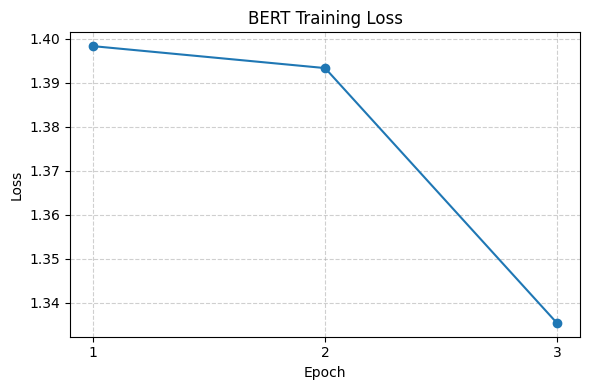

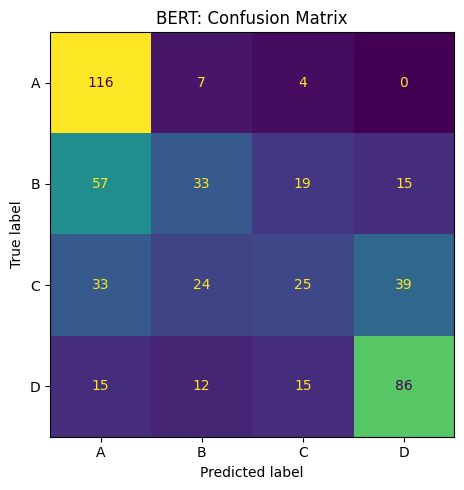


 Training GPT-2
  Epoch 1/3  loss=1.4446
  Epoch 2/3  loss=1.3999
  Epoch 3/3  loss=1.3540


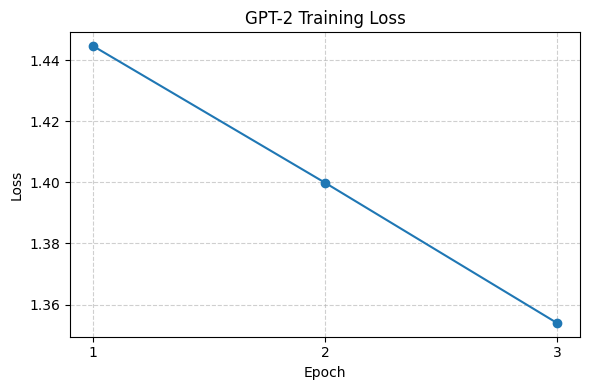

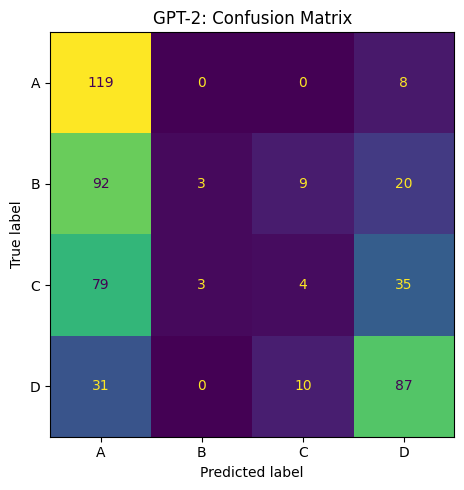


 Training RoBERTa
  Epoch 1/3  loss=1.3921
  Epoch 2/3  loss=1.3914
  Epoch 3/3  loss=1.3859


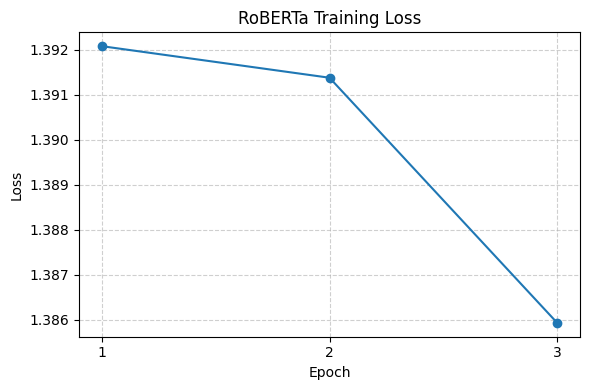

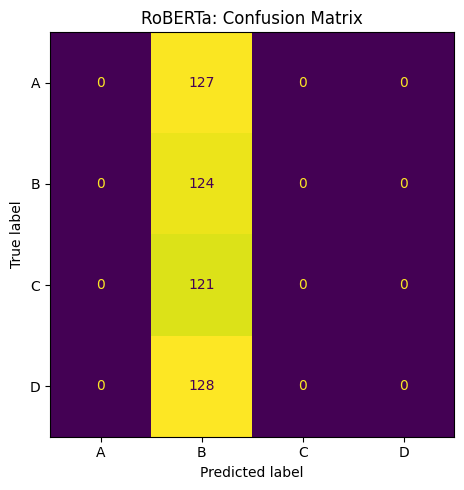


 Training DistilBERT
  Epoch 1/3  loss=1.3898
  Epoch 2/3  loss=1.3110
  Epoch 3/3  loss=1.0309


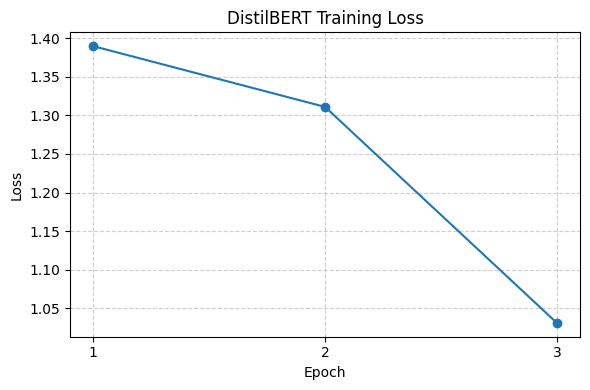

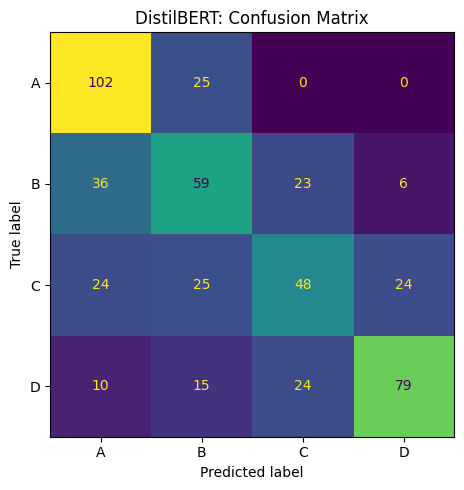

In [19]:
results = []

models = {
    'BERT'      : (bert_model,       bert_train_loader,       bert_test_loader),
    'GPT-2'     : (gpt2_model,       gpt2_train_loader,       gpt2_test_loader),
    'RoBERTa'   : (roberta_model,    roberta_train_loader,    roberta_test_loader),
    'DistilBERT': (distilbert_model, distilbert_train_loader, distilbert_test_loader),
}

for name, (model, train_loader, test_loader) in models.items():

    print(f'\n{"="*50}')
    print(f' Training {name}')
    print(f'{"="*50}')

    losses, train_time = train_model(model, train_loader)

    metrics = evaluate_model(model, test_loader)
    metrics['Model']              = name
    metrics['Training Time (s)'] = round(train_time, 2)
    results.append(metrics)

    # Training loss curve
    plt.figure(figsize=(6, 4))
    plt.plot(losses, marker='o')
    plt.title(f'{name} Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.xticks(range(NUM_EPOCHS), range(1, NUM_EPOCHS + 1))
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # Confusion matrix
    plot_confusion_matrix(model, test_loader, name)


### Section 11: Result Analysis of all Models
> Code for results analysis

In [20]:
results_df = pd.DataFrame(results)

results_df = results_df[
    ['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC', 'Training Time (s)']
]

# Sort by F1 (weighted) : more meaningful than Accuracy for multi-class problems
# because it captures both precision and recall across all four classes.
results_df.sort_values(by='F1', ascending=False)


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Training Time (s)
3,DistilBERT,0.576,0.576443,0.576,0.569520,0.808122,944.89
0,BERT,0.520,0.494294,0.520,0.481233,0.765061,2245.32
1,GPT-2,0.426,0.408729,0.426,0.320058,0.737850,2322.80
2,RoBERTa,0.248,0.061504,0.248,0.098564,0.634418,1974.00


## Reflection Questions

1. `CrossEntropyLoss` was also used in the starter notebook for binary classification. Explain why the same loss function works for both 2-class and 4-class problems. How does it differ mathematically from `BCEWithLogitsLoss`?

CrossEntropyLoss uses softmax over all N logits, turning them into a probability distribution that sums to 1, then takes -log(p_correct). This works for any number of classes, so the same loss extends naturally from 2 to 4 classes. BCEWithLogitsLoss uses sigmoid on each logit independently, treating each class as a separate yes/no decision — that's why it's only suitable for binary or multi-label problems, not single-label multi-class like this one.


2. Why do we use `average='weighted'` rather than `average='macro'` for precision, recall, and F1 in this notebook? In which scenario would `'macro'` be the better choice?

'weighted' averages the per-class precision/recall/F1 scores weighted by how many samples each class actually has, while 'macro' just takes a plain unweighted average across classes. Since our classes (A/B/C/D) are almost perfectly balanced (~3349 each), the two would give nearly the same result here. 'macro' would be better when we specifically care about a rare minority class's performance — e.g. in medical diagnosis, where a model could get high accuracy while completely failing the rare "disease" class, and macro would expose that, but weighted would mask it (this is basically what happened with RoBERTa: 0.248 accuracy but only 0.06 precision, suggesting it collapsed to predicting mostly one class).


3. Explain the `multi_class='ovr'` strategy used in `roc_auc_score`. What AUC score is computed for each class, and how are the four scores combined into a single number?

OVR = One-vs-Rest. For each class, the model's predicted probability for that class is treated as a binary "this class vs all others" classifier, and an AUC is computed for it. This gives 4 AUC values (A-vs-rest, B-vs-rest, C-vs-rest, D-vs-rest). These are then combined into one number using weighted averaging (by class support), same as average='weighted'. This is also why ROC_AUC looks more optimistic than accuracy for weaker models — e.g. RoBERTa got 0.634 AUC despite only 0.248 accuracy, because AUC just measures ranking quality, not whether the final predicted class was correct.


## Extension Exercises

Try the following modifications and note their effect on F1.

1. **Full dataset** : Remove the `.sample(n=2500)` subset and retrain on all ~13 000 samples. Does F1 improve significantly?
2. **Epochs** : Re-train the best model with `NUM_EPOCHS = 5`. Does additional training help or cause overfitting?
3. **Sequence length** : Change `MAX_LENGTH` from 128 to 64. What is the trade-off between speed and accuracy?
4. **Learning rate** : Try `lr=5e-5`. How does a higher learning rate affect convergence and final F1?

> Adjust your code and explain what you observe after each modification, along with possible reasons for those observations.

